# Pipeline debug dump EDA

Exploratory analysis of `.npz` files written by `PipelineDebugDumpMetric` during **Debug metavr AA pipeline (bert24)** (YAML `gena-base-pretrain_metavr_aa_giga.yaml`).

Default dump directory: `runs/moderngena-base-metavr-aa-giga-pipeline-debug/pipeline_debug/` (`encoder_inputs_batch_*.npz`).

Each file holds tensors from `_take_pipeline_debug_snapshot` in `src/bert_layers/model.py`: unpadded encoder inputs (`input_ids`, `indices`, `cu_seqlens`), AA multitask labels, scalar metadata (`batch_idx`, `batch_size`, `seq_len`, `max_seqlen`, `encoder_layout`), and when training with a local `genome_with_translation` dataset, **`meta_*`** fields (`meta_dataset_index`, `meta_shard_index`, `meta_shard_sample_id`, `meta_shard_path`) — these require the collator’s `pipeline_dataset_meta` to reach the model; Composer’s `HuggingFaceModel` only passes batch keys that are **named parameters** on `FlexBertForMaskedLMwAA.forward` (not hidden inside `**kwargs` only).

In [1]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

In [2]:
print("Start")

Start


In [3]:
# Repo root: cwd is either project root or notebooks/
_cwd = Path.cwd().resolve()
REPO_ROOT = _cwd if (_cwd / "main.py").exists() else _cwd.parent

RUN_NAME = "moderngena-base-metavr-aa-giga-pipeline-debug"
DUMP_DIR = REPO_ROOT / "runs" / RUN_NAME / "pipeline_debug"

assert DUMP_DIR.is_dir(), f"Missing dump dir: {DUMP_DIR} — run the debug config first."
npz_paths = sorted(DUMP_DIR.glob("encoder_inputs_batch_*.npz"))
assert npz_paths, f"No encoder_inputs_batch_*.npz under {DUMP_DIR}"
print(f"Found {len(npz_paths)} files under {DUMP_DIR}")

Found 10 files under /disk/10tb/home/fishman/DNALM/ModernBERT/runs/moderngena-base-metavr-aa-giga-pipeline-debug/pipeline_debug


In [4]:
def describe_npz(path: Path) -> dict:
    z = np.load(path, allow_pickle=True)
    row = {"file": path.name}
    for k in sorted(z.files):
        a = z[k]
        row[f"{k}_shape"] = str(a.shape)
        row[f"{k}_dtype"] = str(a.dtype)
    z.close()
    return row


def load_npz(path: Path) -> dict[str, np.ndarray]:
    z = np.load(path, allow_pickle=True)
    return {k: z[k] for k in z.files}


summary_rows = [describe_npz(p) for p in npz_paths]
summary_df = pd.DataFrame(summary_rows)
summary_df

,file,aa_labels_shape,aa_labels_dtype,aa_labels_aligned_for_loss_shape,aa_labels_aligned_for_loss_dtype,attention_mask_shape,attention_mask_dtype,batch_idx_shape,batch_idx_dtype,batch_size_shape,...,meta_dataset_index_shape,meta_dataset_index_dtype,meta_shard_index_shape,meta_shard_index_dtype,meta_shard_path_shape,meta_shard_path_dtype,meta_shard_sample_id_shape,meta_shard_sample_id_dtype,seq_len_shape,seq_len_dtype
0,encoder_inputs_batch_00001.npz,"(1919, 26)",float32,"(1919, 26)",float32,"(2, 1024)",int64,(),int64,(),...,"(2,)",int64,"(2,)",int64,"(2,)",object,"(2,)",int64,(),int64
1,encoder_inputs_batch_00002.npz,"(1339, 26)",float32,"(1339, 26)",float32,"(2, 1024)",int64,(),int64,(),...,"(2,)",int64,"(2,)",int64,"(2,)",object,"(2,)",int64,(),int64
2,encoder_inputs_batch_00003.npz,"(514, 26)",float32,"(514, 26)",float32,"(2, 1024)",int64,(),int64,(),...,"(2,)",int64,"(2,)",int64,"(2,)",object,"(2,)",int64,(),int64
3,encoder_inputs_batch_00004.npz,"(790, 26)",float32,"(790, 26)",float32,"(2, 1024)",int64,(),int64,(),...,"(2,)",int64,"(2,)",int64,"(2,)",object,"(2,)",int64,(),int64
4,encoder_inputs_batch_00005.npz,"(569, 26)",float32,"(569, 26)",float32,"(2, 1024)",int64,(),int64,(),...,"(2,)",int64,"(2,)",int64,"(2,)",object,"(2,)",int64,(),int64
5,encoder_inputs_batch_00006.npz,"(1816, 26)",float32,"(1816, 26)",float32,"(2, 1024)",int64,(),int64,(),...,"(2,)",int64,"(2,)",int64,"(2,)",object,"(2,)",int64,(),int64
6,encoder_inputs_batch_00007.npz,"(509, 26)",float32,"(509, 26)",float32,"(2, 1024)",int64,(),int64,(),...,"(2,)",int64,"(2,)",int64,"(2,)",object,"(2,)",int64,(),int64
7,encoder_inputs_batch_00008.npz,"(686, 26)",float32,"(686, 26)",float32,"(2, 1024)",int64,(),int64,(),...,"(2,)",int64,"(2,)",int64,"(2,)",object,"(2,)",int64,(),int64
8,encoder_inputs_batch_00009.npz,"(1263, 26)",float32,"(1263, 26)",float32,"(2, 1024)",int64,(),int64,(),...,"(2,)",int64,"(2,)",int64,"(2,)",object,"(2,)",int64,(),int64
9,encoder_inputs_batch_00010.npz,"(388, 26)",float32,"(388, 26)",float32,"(2, 1024)",int64,(),int64,(),...,"(2,)",int64,"(2,)",int64,"(2,)",object,"(2,)",int64,(),int64


In [5]:
def cu_seqlens_to_lengths(cu: np.ndarray) -> np.ndarray:
    cu = np.asarray(cu).astype(np.int64)
    return np.diff(cu)


def aa_valid_mask(aa: np.ndarray) -> np.ndarray:
    """Positions where any AA dimension is supervised (not -100)."""
    return (aa != -100).any(axis=-1)


stats = []
for p in npz_paths:
    d = load_npz(p)
    cu = d["cu_seqlens"]
    lens = cu_seqlens_to_lengths(cu)
    nnz = int(d["input_ids"].shape[0])
    aa = d.get("aa_labels")
    if aa is not None:
        valid = aa_valid_mask(aa)
        n_aa_pos = int(valid.sum())
        # among supervised cells, value distribution
        sup = aa[valid]
        n_zero = int((sup == 0).sum())
        n_one = int((sup == 1).sum())
    else:
        n_aa_pos = n_zero = n_one = 0
    stats.append(
        {
            "file": p.name,
            "batch_idx": int(d["batch_idx"].item()) if d["batch_idx"].shape == () else int(d["batch_idx"]),
            "batch_size_meta": int(d["batch_size"].item()),
            "seq_len_meta": int(d["seq_len"].item()),
            "max_seqlen": int(d["max_seqlen"].item()),
            "encoder_layout": str(d["encoder_layout"].item()),
            "num_sequences": len(lens),
            "total_tokens_nnz": nnz,
            "seq_len_min": int(lens.min()),
            "seq_len_max": int(lens.max()),
            "seq_len_mean": float(lens.mean()),
            "aa_supervised_positions": n_aa_pos,
            "aa_cells_eq_0": n_zero,
            "aa_cells_eq_1": n_one,
        }
    )

stats_df = pd.DataFrame(stats).sort_values("batch_idx")
stats_df

,file,batch_idx,batch_size_meta,seq_len_meta,max_seqlen,encoder_layout,num_sequences,total_tokens_nnz,seq_len_min,seq_len_max,seq_len_mean,aa_supervised_positions,aa_cells_eq_0,aa_cells_eq_1
0,encoder_inputs_batch_00001.npz,1,2,1024,1010,unpadded,2,1919,909,1010,959.5,1915,44746,4941
1,encoder_inputs_batch_00002.npz,2,2,1024,1024,unpadded,2,1339,315,1024,669.5,1335,30327,4235
2,encoder_inputs_batch_00003.npz,3,2,1024,308,unpadded,2,514,206,308,257.0,510,11615,1629
3,encoder_inputs_batch_00004.npz,4,2,1024,569,unpadded,2,790,221,569,395.0,786,18476,1893
4,encoder_inputs_batch_00005.npz,5,2,1024,333,unpadded,2,569,236,333,284.5,565,12855,1720
5,encoder_inputs_batch_00006.npz,6,2,1024,1024,unpadded,2,1816,792,1024,908.0,1812,42124,4791
6,encoder_inputs_batch_00007.npz,7,2,1024,257,unpadded,2,509,252,257,254.5,505,11790,1310
7,encoder_inputs_batch_00008.npz,8,2,1024,410,unpadded,2,686,276,410,343.0,682,15914,1707
8,encoder_inputs_batch_00009.npz,9,2,1024,953,unpadded,2,1263,310,953,631.5,1259,29705,2890
9,encoder_inputs_batch_00010.npz,10,2,1024,252,unpadded,2,388,136,252,194.0,384,8711,1218


First file sequence lengths: [909, 1010]
input_ids nnz: 1919 sum(lens): 1919


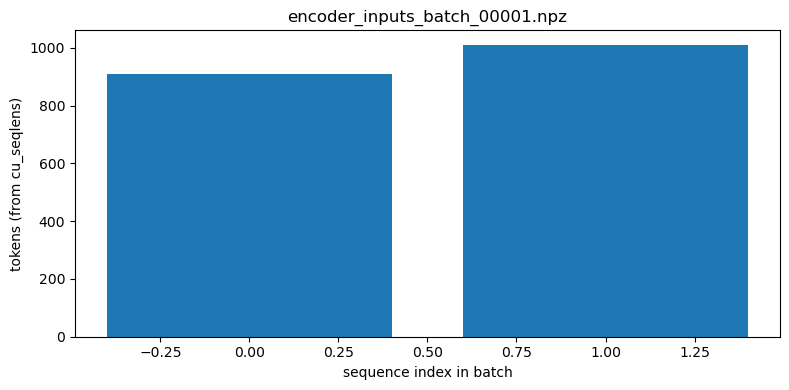

In [6]:
# Per-batch sequence length lists (for histograms)
first = load_npz(npz_paths[0])
lens0 = cu_seqlens_to_lengths(first["cu_seqlens"])
print("First file sequence lengths:", lens0.tolist())
print("input_ids nnz:", first["input_ids"].shape[0], "sum(lens):", int(lens0.sum()))

if plt is not None:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(np.arange(len(lens0)), lens0)
    ax.set_xlabel("sequence index in batch")
    ax.set_ylabel("tokens (from cu_seqlens)")
    ax.set_title(npz_paths[0].name)
    plt.tight_layout()
    plt.show()
else:
    print("Install matplotlib for plots.")

/disk/10tb/home/fishman/miniconda3/envs/bert24/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/disk/10tb/home/fishman/miniconda3/envs/bert24/lib/python3.11/site-packages/flash_attn/ops/triton/layer_norm.py:958: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd
/disk/10tb/home/fishman/miniconda3/envs/bert24/lib/python3.11/site-packages/flash_attn/ops/triton/layer_norm.py:1017: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  @custom_bwd


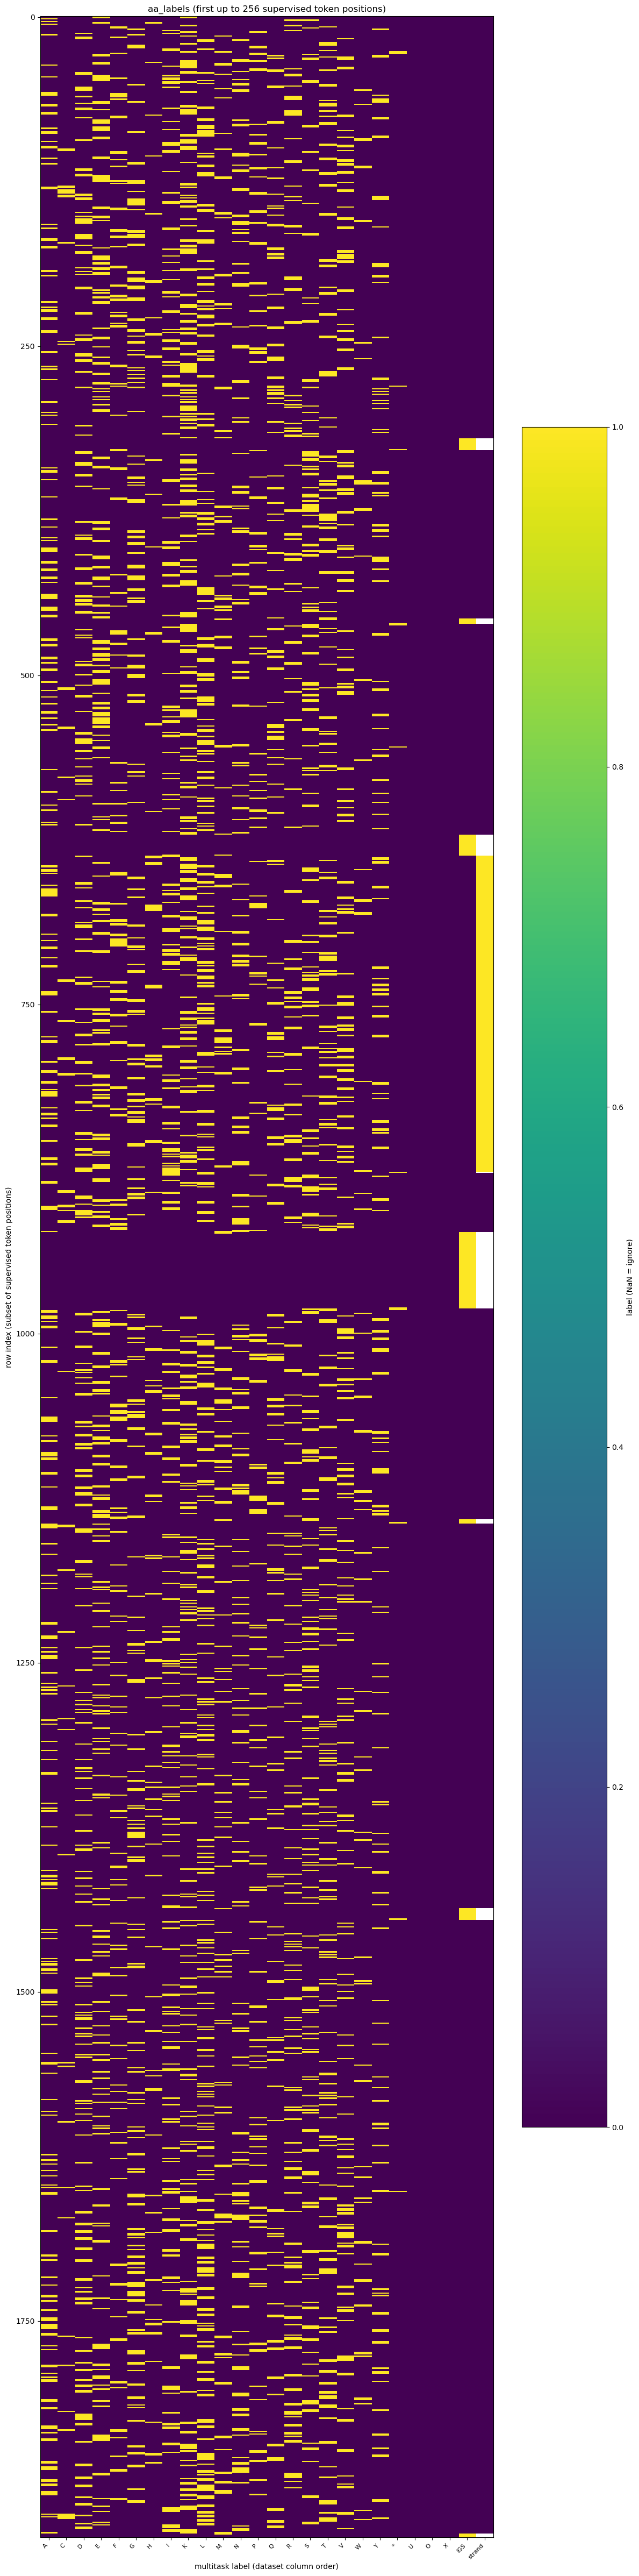

In [7]:
# AA label heatmap: first N supervised rows of token positions (unpadded stream)
import sys

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
from src.text_data import NoStreamingGenomeAndProteinDataset

_aa_x_labels = NoStreamingGenomeAndProteinDataset.aa_list + ["strand"]

aa = first["aa_labels"]
assert len(_aa_x_labels) == aa.shape[1], (len(_aa_x_labels), aa.shape[1])
valid_row = aa_valid_mask(aa)
idx = np.flatnonzero(valid_row) #[:256]
if len(idx) == 0:
    print("No supervised AA rows in first batch")
else:
    sub = aa[idx]
    # map -100 -> nan for imshow
    vis = sub.astype(np.float64)
    vis[vis == -100] = np.nan
    if plt is not None:
        fig, ax = plt.subplots(figsize=(12, 48))
        im = ax.imshow(vis, aspect="auto", interpolation="nearest", vmin=0, vmax=1)
        ax.set_xticks(np.arange(aa.shape[1]))
        ax.set_xticklabels(_aa_x_labels, rotation=45, ha="right", fontsize=8)
        ax.set_xlabel("multitask label (dataset column order)")
        ax.set_ylabel("row index (subset of supervised token positions)")
        plt.colorbar(im, ax=ax, label="label (NaN = ignore)")
        ax.set_title("aa_labels (first up to 256 supervised token positions)")
        plt.tight_layout()
        plt.show()
    else:
        print("sub array shape", sub.shape, "finite fraction", np.isfinite(vis).mean())

In [8]:
# Optional: decode a single sequence with the same tokenizer as training (6-mer path from YAML)
tok_path = REPO_ROOT / "data" / "tokenizers" / "6mer"
if tok_path.exists():
    from transformers import AutoTokenizer

    tok = AutoTokenizer.from_pretrained(str(tok_path), trust_remote_code=True)
    cu = first["cu_seqlens"]
    s0, s1 = int(cu[0]), int(cu[1])
    ids = first["input_ids"][s0:s1]
    # skip special tokens in print if very long
    text = tok.decode(ids.tolist(), skip_special_tokens=False)
    print("First sequence token count:", len(ids))
    print("Decode preview (first 500 chars):\n", text[:500])
else:
    print(f"Tokenizer not found at {tok_path}; skip decode.")

First sequence token count: 909
Decode preview (first 500 chars):
 [CLS] [MASK] [MASK] tgcagc tctact cgctgc ttcgtg [MASK] tttacg tgtaaa [MASK] [MASK] aatgcg [MASK] [MASK] [MASK] cttcat aaaatc agaact [MASK] taatag [MASK] [MASK] acctgt acctgg [MASK] [MASK] aattgt [MASK] tagaac [MASK] tcctga taagtt acttgg cttacg tttggt ttatgt [MASK] [MASK] [MASK] ttaaca acacgt ggagtt tgattt tttaaa [MASK] [MASK] tctgct tcaaat atattt tctaaa [MASK] [MASK] ttaccg gttctt [MASK] tccatg tcccag ttattc ttttta gcaaac ctcagg aaatct [MASK] [MASK] [MASK] taacct [MASK] gtccat gcagtt [MASK] [MAS


/disk/10tb/home/fishman/miniconda3/envs/bert24/lib/python3.11/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


## First 1000 tokens: 6-mer / special strings and AA multitask labels

Uses the first sequence in the first dump batch (`cu_seqlens` slice). **AA columns** match `NoStreamingGenomeAndProteinDataset.aa_list` (25) plus **`strand`** — same order as `flex_bert_mlm_aa` / `num_aa_labels: 26`. For each token we show k-mers via `convert_ids_to_tokens` and list amino-acid names where the label is **1** (binary targets); **—** means all positions ignored (`-100`). When the dump includes **`labels`** (MLM targets from `_take_pipeline_debug_snapshot`), **`mlm_label_id`** / **`mlm_label`** show the supervised token id and its decoded string; **`—`** in **`mlm_label`** means ignore index (`-100`, no MLM loss). The **merged** dataframe in the codon section below rewrites **`aa_labels (positives)`** so each symbol is followed by **all encoding codons** from the same bacterial code (e.g. `A (GCA, GCC, GCT, GCG)`); labels without a codon set (`strand`, `X`, `IGS`) stay unbracketed.

In [9]:
import sys

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.text_data import NoStreamingGenomeAndProteinDataset
from transformers import AutoTokenizer

AA_LABEL_NAMES = NoStreamingGenomeAndProteinDataset.aa_list + ["strand"]
n_aa = first["aa_labels"].shape[1]
assert len(AA_LABEL_NAMES) == n_aa, (len(AA_LABEL_NAMES), n_aa)

tok_path = REPO_ROOT / "data" / "tokenizers" / "6mer"
assert tok_path.is_dir(), f"Missing tokenizer: {tok_path}"
tok = AutoTokenizer.from_pretrained(str(tok_path), trust_remote_code=True)


def id_to_kmer_or_special(token_id: int) -> str:
    piece = tok.convert_ids_to_tokens(int(token_id))
    if isinstance(piece, list):
        piece = piece[0] if piece else str(token_id)
    s = str(piece)
    if s.startswith("##"):
        s = s[2:]
    return s


def format_aa_labels(row: np.ndarray) -> str:
    if np.all(row == -100):
        return "—"
    active = [AA_LABEL_NAMES[i] for i in range(n_aa) if row[i] == 1]
    return ", ".join(active) if active else "(no positive)"


N_TOKENS = 1000
cu = first["cu_seqlens"]
s0, s1 = int(cu[0]), int(cu[1])
end = min(s0 + N_TOKENS, s1)
ids_seg = first["input_ids"][s0:end]
aa_seg = first["aa_labels"][s0:end]

MLM_IGNORE = -100
if "labels" in first:
    lab = np.asarray(first["labels"]).reshape(-1)
    assert lab.shape[0] == first["input_ids"].shape[0], (lab.shape, first["input_ids"].shape)
    labels_seg = lab[s0:end]
else:
    labels_seg = None

rows = []
for k in range(len(ids_seg)):
    tid = int(ids_seg[k])
    row = {
        "pos_in_seq": k,
        "token_id": tid,
        "dna_token": id_to_kmer_or_special(tid),
        "aa_labels (positives)": format_aa_labels(aa_seg[k]),
    }
    if labels_seg is not None:
        lid = int(labels_seg[k])
        row["mlm_label_id"] = lid
        row["mlm_label"] = "—" if lid == MLM_IGNORE else id_to_kmer_or_special(lid)
    rows.append(row)

token_aa_df = pd.DataFrame(rows)
token_aa_df

,pos_in_seq,token_id,dna_token,aa_labels (positives),mlm_label_id,mlm_label
0,0,1,[CLS],—,-100,—
1,1,4,[MASK],"F, N",276,taaa
2,2,4,[MASK],"E, K",2859,tttttc
3,3,3231,tgcagc,A,-100,—
4,4,3361,tctact,"R, S",-100,—
...,...,...,...,...,...,...
904,904,2375,actcac,"C, E, F",-100,—
905,905,1574,aattag,"A, C, N",1574,aattag
906,906,5516,ccgcga,"A, I",-100,—
907,907,4,[MASK],"A, I, W",3490,tccacg


### Codon-in-6mer check (bacterial / NCBI transl. table 11)

**Both strands:** for each 6-mer we take overlapping 3-mers on the **forward (stored) sequence** (4 windows) and on its **reverse complement**, then **union** them. **`codon_hit`** (and `trimers_union`) use that union — a codon counts if it appears on **either** strand within the 6 bp.

**Strand target** (multitask channel `strand`, from `strand[:,0]` in `text_data.py`): it is **not** compared to a genetic-code table. When it is supervised (**0** or **1**), we also compute **`codon_hit_strand_gated`**: **0 → forward trimers only**, **1 → reverse-complement trimers only**. When `strand` is **-100**, orientation is treated as unknown and gating uses the **same union as above**.

Positive **amino-acid** labels still exclude **`X`** and **`IGS`** from codon matching. **`[CLS]`**, **`[MASK]`**, etc. are skipped when not a pure DNA 6-mer. **U** → **TGA**; **O** → **UAG** (simplified).

In [10]:
# NCBI translation table 11 (bacterial/archaeal/plastid): codon -> one-letter AA
# Matches table 1 for all triplets below.
_CODON_AA = {
    "TTT": "F",
    "TTC": "F",
    "TTA": "L",
    "TTG": "L",
    "CTT": "L",
    "CTC": "L",
    "CTA": "L",
    "CTG": "L",
    "ATT": "I",
    "ATC": "I",
    "ATA": "I",
    "ATG": "M",
    "GTT": "V",
    "GTC": "V",
    "GTA": "V",
    "GTG": "V",
    "TCT": "S",
    "TCC": "S",
    "TCA": "S",
    "TCG": "S",
    "AGT": "S",
    "AGC": "S",
    "CCT": "P",
    "CCC": "P",
    "CCA": "P",
    "CCG": "P",
    "ACT": "T",
    "ACC": "T",
    "ACA": "T",
    "ACG": "T",
    "GCT": "A",
    "GCC": "A",
    "GCA": "A",
    "GCG": "A",
    "TAT": "Y",
    "TAC": "Y",
    "TAA": "*",
    "TAG": "*",
    "CAT": "H",
    "CAC": "H",
    "CAA": "Q",
    "CAG": "Q",
    "AAT": "N",
    "AAC": "N",
    "AAA": "K",
    "AAG": "K",
    "GAT": "D",
    "GAC": "D",
    "GAA": "E",
    "GAG": "E",
    "TGT": "C",
    "TGC": "C",
    "TGA": "*",
    "TGG": "W",
    "CGT": "R",
    "CGC": "R",
    "CGA": "R",
    "CGG": "R",
    "AGA": "R",
    "AGG": "R",
    "GGT": "G",
    "GGC": "G",
    "GGA": "G",
    "GGG": "G",
}

AA_TO_CODONS: dict[str, frozenset[str]] = {}
for codon, aa in _CODON_AA.items():
    AA_TO_CODONS.setdefault(aa, set()).add(codon)
# Selenocysteine / pyrrolysine (not in the 64-codon map above)
AA_TO_CODONS["U"] = AA_TO_CODONS.get("U", set()) | {"TGA"}
AA_TO_CODONS["O"] = AA_TO_CODONS.get("O", set()) | {"UAG"}
AA_TO_CODONS = {k: frozenset(v) for k, v in AA_TO_CODONS.items()}


def format_aa_labels_with_codons(row: np.ndarray) -> str:
    """Positive labels with all bacterial-code DNA codons per symbol in brackets."""
    if np.all(row == -100):
        return "—"
    parts: list[str] = []
    for i in range(n_aa):
        if row[i] != 1:
            continue
        name = AA_LABEL_NAMES[i]
        codons = AA_TO_CODONS.get(name)
        if codons:
            cstr = ", ".join(sorted(codons))
            parts.append(f"{name} ({cstr})")
        else:
            parts.append(name)
    return ", ".join(parts) if parts else "(no positive)"


SKIP_CODON_CHECK = frozenset({"strand", "X", "IGS"})
STRAND_IDX = AA_LABEL_NAMES.index("strand")


def overlapping_trimers(dna_token: str) -> frozenset[str]:
    s = dna_token.upper().replace("U", "T")
    if len(s) < 3 or not set(s).issubset(set("ACGTN")):
        return frozenset()
    return frozenset(s[i : i + 3] for i in range(len(s) - 2))


def revcomp(seq: str) -> str:
    s = seq.upper().replace("U", "T")
    comp = s.translate(str.maketrans("ACGTN", "TGCAN"))
    return comp[::-1]


def positive_aas_from_row(row: np.ndarray) -> list[str]:
    return [AA_LABEL_NAMES[i] for i in range(n_aa) if row[i] == 1]


def aa_has_codon_in_trimers(aa: str, trimers: frozenset[str]) -> bool:
    if aa in SKIP_CODON_CHECK:
        return False
    codons = AA_TO_CODONS.get(aa)
    if not codons:
        return False
    return bool(trimers & codons)


def row_codon_hits(row_aa: np.ndarray, dna_token: str) -> dict:
    """Forward + RC trimers; union hit; strand-gated hit when strand ∈ {0,1}."""
    fwd = overlapping_trimers(dna_token)
    sv = float(row_aa[STRAND_IDX])
    pos = positive_aas_from_row(row_aa)
    tested = [a for a in pos if a not in SKIP_CODON_CHECK]
    out = {
        "strand_target": sv,
        "trimers_fwd": fwd,
        "trimers_rc": frozenset(),
        "trimers_union": frozenset(),
        "codon_hit": None,
        "codon_hit_fwd_only": None,
        "codon_hit_rc_only": None,
        "codon_hit_strand_gated": None,
        "n_pos_aa_checked": len(tested),
    }
    if not fwd:
        return out
    rc = overlapping_trimers(revcomp(dna_token))
    uni = fwd | rc
    out["trimers_rc"] = rc
    out["trimers_union"] = uni
    if not tested:
        return out

    def any_hit(tset: frozenset[str]) -> bool:
        return any(aa_has_codon_in_trimers(a, tset) for a in tested)

    hf = any_hit(fwd)
    hr = any_hit(rc)
    out["codon_hit_fwd_only"] = hf
    out["codon_hit_rc_only"] = hr
    out["codon_hit"] = hf or hr
    if sv == 0.0:
        out["codon_hit_strand_gated"] = hf
    elif sv == 1.0:
        out["codon_hit_strand_gated"] = hr
    else:
        out["codon_hit_strand_gated"] = hf or hr
    return out


hits = []
for k in range(len(aa_seg)):
    dna = id_to_kmer_or_special(int(ids_seg[k]))
    r = row_codon_hits(aa_seg[k], dna)
    hits.append(
        {
            "pos_in_seq": k,
            "dna_token": dna,
            "strand_target": r["strand_target"],
            "trimers_fwd": ", ".join(sorted(r["trimers_fwd"])) if r["trimers_fwd"] else "",
            "trimers_rc": ", ".join(sorted(r["trimers_rc"])) if r["trimers_rc"] else "",
            "trimers_union": ", ".join(sorted(r["trimers_union"])) if r["trimers_union"] else "",
            "codon_hit": r["codon_hit"],
            "codon_hit_fwd_only": r["codon_hit_fwd_only"],
            "codon_hit_rc_only": r["codon_hit_rc_only"],
            "codon_hit_strand_gated": r["codon_hit_strand_gated"],
            "n_pos_aa_checked": r["n_pos_aa_checked"],
        }
    )

codon_df = pd.DataFrame(hits)
applicable = codon_df["codon_hit"].notna()
with_labels = applicable & (codon_df["n_pos_aa_checked"] > 0)

n_app = int(with_labels.sum())
if n_app:
    rate_union = codon_df.loc[with_labels, "codon_hit"].astype(bool).mean()
    print(
        f"Among {n_app} DNA 6-mer tokens with ≥1 AA label (excl. strand/X/IGS):\n"
        f"  codon_hit (forward ∪ reverse-complement 3-mers): {rate_union:.3f}"
    )
    wf = with_labels & codon_df["codon_hit_fwd_only"].notna()
    wr = with_labels & codon_df["codon_hit_rc_only"].notna()
    if int(wf.sum()):
        print(
        f"  forward-only hit rate: {codon_df.loc[wf, 'codon_hit_fwd_only'].astype(bool).mean():.3f}"
    )
    if int(wr.sum()):
        print(
        f"  RC-only hit rate: {codon_df.loc[wr, 'codon_hit_rc_only'].astype(bool).mean():.3f}"
    )
    gated_ok = with_labels & codon_df["strand_target"].isin([0.0, 1.0])
    ng = int(gated_ok.sum())
    if ng:
        rate_g = codon_df.loc[gated_ok, "codon_hit_strand_gated"].astype(bool).mean()
        print(
        f"Among {ng} rows with supervised strand (0 or 1), codon_hit_strand_gated: {rate_g:.3f}"
    )
else:
    print("No applicable rows (need DNA 6-mers with positive AA labels).")

print(
    "(NaN codon_hit = not a DNA 6-mer, or no AA labels to test after excl. strand/X/IGS)"
)

merged = token_aa_df.assign(
    strand_target=codon_df["strand_target"],
    codon_hit=codon_df["codon_hit"],
    codon_hit_strand_gated=codon_df["codon_hit_strand_gated"],
    codon_hit_fwd_only=codon_df["codon_hit_fwd_only"],
    codon_hit_rc_only=codon_df["codon_hit_rc_only"],
    trimers_union=codon_df["trimers_union"],
    trimers_fwd=codon_df["trimers_fwd"],
    trimers_rc=codon_df["trimers_rc"],
)
merged["aa_labels (positives)"] = [
    format_aa_labels_with_codons(aa_seg[k]) for k in range(len(aa_seg))
]
merged

Among 670 DNA 6-mer tokens with ≥1 AA label (excl. strand/X/IGS):
  codon_hit (forward ∪ reverse-complement 3-mers): 0.985
  forward-only hit rate: 0.616
  RC-only hit rate: 0.845
Among 667 rows with supervised strand (0 or 1), codon_hit_strand_gated: 0.486
(NaN codon_hit = not a DNA 6-mer, or no AA labels to test after excl. strand/X/IGS)


,pos_in_seq,token_id,dna_token,aa_labels (positives),mlm_label_id,mlm_label,strand_target,codon_hit,codon_hit_strand_gated,codon_hit_fwd_only,codon_hit_rc_only,trimers_union,trimers_fwd,trimers_rc
0,0,1,[CLS],—,-100,—,-100.0,None,None,None,None,,,
1,1,4,[MASK],"F (TTC, TTT), N (AAC, AAT)",276,taaa,0.0,None,None,None,None,,,
2,2,4,[MASK],"E (GAA, GAG), K (AAA, AAG)",2859,tttttc,0.0,None,None,None,None,,,
3,3,3231,tgcagc,"A (GCA, GCC, GCG, GCT)",-100,—,0.0,True,True,True,True,"AGC, CAG, CTG, GCA, GCT, TGC","AGC, CAG, GCA, TGC","CTG, GCA, GCT, TGC"
4,4,3361,tctact,"R (AGA, AGG, CGA, CGC, CGG, CGT), S (AGC, AGT,...",-100,—,0.0,True,True,True,True,"ACT, AGA, AGT, CTA, GTA, TAC, TAG, TCT","ACT, CTA, TAC, TCT","AGA, AGT, GTA, TAG"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
904,904,2375,actcac,"C (TGC, TGT), E (GAA, GAG), F (TTC, TTT)",-100,—,0.0,True,False,False,True,"ACT, AGT, CAC, CTC, GAG, GTG, TCA, TGA","ACT, CAC, CTC, TCA","AGT, GAG, GTG, TGA"
905,905,1574,aattag,"A (GCA, GCC, GCG, GCT), C (TGC, TGT), N (AAC, ...",1574,aattag,0.0,True,True,True,True,"AAT, ATT, CTA, TAA, TAG, TTA","AAT, ATT, TAG, TTA","AAT, ATT, CTA, TAA"
906,906,5516,ccgcga,"A (GCA, GCC, GCG, GCT), I (ATA, ATC, ATT)",-100,—,0.0,True,True,True,True,"CCG, CGA, CGC, CGG, GCG, TCG","CCG, CGA, CGC, GCG","CGC, CGG, GCG, TCG"
907,907,4,[MASK],"A (GCA, GCC, GCG, GCT), I (ATA, ATC, ATT), W (...",3490,tccacg,0.0,None,None,None,None,,,


In [11]:
merged[merged["codon_hit"]==False]

,pos_in_seq,token_id,dna_token,aa_labels (positives),mlm_label_id,mlm_label,strand_target,codon_hit,codon_hit_strand_gated,codon_hit_fwd_only,codon_hit_rc_only,trimers_union,trimers_fwd,trimers_rc
61,61,5022,ctcagg,"A (GCA, GCC, GCG, GCT), F (TTC, TTT), Y (TAC, ...",4324,gcataa,0.0,False,False,False,False,"AGG, CAG, CCT, CTC, CTG, GAG, TCA, TGA","AGG, CAG, CTC, TCA","CCT, CTG, GAG, TGA"
117,117,1823,attagc,"D (GAC, GAT), P (CCA, CCC, CCG, CCT)",4156,ggtgga,0.0,False,False,False,False,"AAT, AGC, ATT, CTA, GCT, TAA, TAG, TTA","AGC, ATT, TAG, TTA","AAT, CTA, GCT, TAA"
159,159,1892,atgtaa,"A (GCA, GCC, GCG, GCT), N (AAC, AAT), Q (CAA, ...",2817,ttagct,0.0,False,False,False,False,"ACA, ATG, CAT, GTA, TAA, TAC, TGT, TTA","ATG, GTA, TAA, TGT","ACA, CAT, TAC, TTA"
175,175,234,attg,"D (GAC, GAT), G (GGA, GGC, GGG, GGT), K (AAA, ...",5491,ccgtcc,0.0,False,False,False,False,"AAT, ATT, CAA, TTG","ATT, TTG","AAT, CAA"
319,319,192,gca,"D (GAC, GAT), R (AGA, AGG, CGA, CGC, CGG, CGT)",1969,atctct,0.0,False,False,False,False,"GCA, TGC",GCA,TGC
347,347,2941,ttgggt,"A (GCA, GCC, GCG, GCT), Y (TAC, TAT)",4546,gccgcg,0.0,False,False,False,False,"ACC, CAA, CCA, CCC, GGG, GGT, TGG, TTG","GGG, GGT, TGG, TTG","ACC, CAA, CCA, CCC"
499,499,4795,cacgtc,"E (GAA, GAG), K (AAA, AAG), N (AAC, AAT)",4649,catttt,0.0,False,False,False,False,"ACG, CAC, CGT, GAC, GTC, GTG","ACG, CAC, CGT, GTC","ACG, CGT, GAC, GTG"
543,543,1259,cattc,"A (GCA, GCC, GCG, GCT), L (CTA, CTC, CTG, CTT,...",1680,aagcca,0.0,False,False,False,False,"AAT, ATG, ATT, CAT, GAA, TTC","ATT, CAT, TTC","AAT, ATG, GAA"
549,549,5032,ctctta,"Q (CAA, CAG)",3905,gttgct,0.0,False,False,False,False,"AAG, AGA, CTC, CTT, GAG, TAA, TCT, TTA","CTC, CTT, TCT, TTA","AAG, AGA, GAG, TAA"
567,567,5184,cgtgca,"L (CTA, CTC, CTG, CTT, TTA, TTG)",4598,caagag,0.0,False,False,False,False,"ACG, CAC, CGT, GCA, GTG, TGC","CGT, GCA, GTG, TGC","ACG, CAC, GCA, TGC"


In [12]:
# Trace one `codon_hit == False` row back to Mosaic shard + sample id.
# `token_aa_df` / `merged` use the first sequence in the dump → batch slot 0.
# `meta_*` keys require dumps from a build where `pipeline_dataset_meta` is a *named*
# argument on `FlexBertForMaskedLMwAA.forward` (Composer only forwards batch keys that
# appear on the model signature — **kwargs alone does not receive collator fields).
# Re-run pipeline-debug training after that fix; set `RUN_NAME` / `DUMP_DIR` to the new run.

SEQ_BATCH_SLOT = 0
miss = merged.loc[merged["codon_hit"].eq(False) & merged["codon_hit"].notna()]
need_meta = (
    "meta_shard_path",
    "meta_shard_sample_id",
    "meta_dataset_index",
    "meta_shard_index",
)
z0 = load_npz(npz_paths[0])

if miss.empty:
    print("No rows with codon_hit == False (among labeled DNA 6-mers).")
elif not all(k in z0 for k in need_meta):
    ex = miss.iloc[0]
    print("Example codon_miss row (no meta in this .npz — re-run debug training to record shard provenance):")
    _ex_cols = ["pos_in_seq", "token_id", "dna_token"]
    if "mlm_label_id" in miss.columns:
        _ex_cols.extend(["mlm_label_id", "mlm_label"])
    _ex_cols.extend(["aa_labels (positives)", "codon_hit"])
    print(ex[_ex_cols].to_string())
    print("npz:", npz_paths[0].name, "| batch_idx:", int(z0["batch_idx"].item()) if z0["batch_idx"].shape == () else z0["batch_idx"])
else:
    ex = miss.iloc[0]
    md_i = SEQ_BATCH_SLOT

    def _slot_int(key: str) -> int:
        a = z0[key]
        if a.shape == ():
            return int(a.item())
        return int(a.reshape(-1)[md_i])

    paths = z0["meta_shard_path"]
    if paths.shape == ():
        shard_path = str(paths.item())
    else:
        shard_path = str(paths.reshape(-1)[md_i])

    print("Example merged row (codon_hit == False):")
    print(ex.to_string())
    print()
    print("Provenance (batch slot %d, file %s):" % (md_i, npz_paths[0].name))
    print("  dataset_index (NoStreamingGenomeAndProteinDataset / sampler order):", _slot_int("meta_dataset_index"))
    print("  shard_index (order in split index.json):", _slot_int("meta_shard_index"))
    print("  shard_sample_id (row index inside that shard):", _slot_int("meta_shard_sample_id"))
    print("  shard_path (raw mosaic shard file):", shard_path)


Example merged row (codon_hit == False):
pos_in_seq                                                               61
token_id                                                               5022
dna_token                                                            ctcagg
aa_labels (positives)     A (GCA, GCC, GCG, GCT), F (TTC, TTT), Y (TAC, ...
mlm_label_id                                                           4324
mlm_label                                                            gcataa
strand_target                                                           0.0
codon_hit                                                             False
codon_hit_strand_gated                                                False
codon_hit_fwd_only                                                    False
codon_hit_rc_only                                                     False
trimers_union                        AGG, CAG, CCT, CTC, CTG, GAG, TCA, TGA
trimers_fwd                                    

In [13]:
# Raw MDS row by (shard_index, shard_sample_id) — same shard table as NoStreamingDataset.__getitem__
# (shard_id, shard_sample_id) = spanner[dataset_index]; here we index the shard list directly.
import sys

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.text_data import NoStreamingDataset, NoStreamingGenomeAndProteinDataset

# Same as yamls/moderngena/gena-base-pretrain_metavr_aa_giga.yaml → train_loader.dataset
DATA_LOCAL = REPO_ROOT / "data/omg_test/omg-train-00000-of-03789."
DATA_SPLIT = "train"
MAX_SEQ_LEN = 1024

# # From your dump meta, or set manually: shards[SHARD_INDEX][SHARD_SAMPLE_ID]
# z0 = load_npz(npz_paths[0])
# SEQ_BATCH_SLOT = 0
# if "meta_shard_index" in z0 and "meta_shard_sample_id" in z0:
#     _mi = z0["meta_shard_index"]
#     _ms = z0["meta_shard_sample_id"]
#     SHARD_INDEX = int(_mi.item()) if _mi.shape == () else int(_mi.reshape(-1)[SEQ_BATCH_SLOT])
#     SHARD_SAMPLE_ID = int(_ms.item()) if _ms.shape == () else int(_ms.reshape(-1)[SEQ_BATCH_SLOT])
# else:
SHARD_INDEX = 4
SHARD_SAMPLE_ID = 70

local = str(DATA_LOCAL.resolve())
ds = NoStreamingDataset(local, DATA_SPLIT, max_seq_len=MAX_SEQ_LEN, tokenizer=None)
assert 0 <= SHARD_INDEX < len(ds.shards), f"shard_index {SHARD_INDEX} out of range (n_shards={len(ds.shards)})"
shard = ds.shards[SHARD_INDEX]
assert 0 <= SHARD_SAMPLE_ID < shard.samples, f"shard_sample_id {SHARD_SAMPLE_ID} out of range (samples={shard.samples})"
raw_sample = shard[SHARD_SAMPLE_ID]

print(f"Opened shards like NoStreamingDataset: local={local!r} split={DATA_SPLIT!r}")
print(f"shards[{SHARD_INDEX}][{SHARD_SAMPLE_ID}]  ->  keys: {sorted(raw_sample.keys())}")
cds_ids, nt_seq, min_start, strand, aa = NoStreamingGenomeAndProteinDataset.unpack_sample(raw_sample)
print("CDS_ids count:", len(cds_ids), "| min_start:", min_start, "| nt_seq len:", len(nt_seq))
print("nt_seq preview:", nt_seq[:120] + ("..." if len(nt_seq) > 120 else ""))


Opened shards like NoStreamingDataset: local='/disk/10tb/home/fishman/DNALM/ModernBERT/data/omg_test/omg-train-00000-of-03789.' split='train'
shards[4][70]  ->  keys: ['CDS_ids', 'aa_array', 'min_start', 'nt_seq', 'strand_array']
CDS_ids count: 9 | min_start: 1017 | nt_seq len: 7427
nt_seq preview: TTAATCATATTGTGCTTTAAGTTTATTTAAGAACCAAATTGCTTTGTCTAGATCTTCGACAGGTTTACCTTTGTGTTCGTGCCGCCAAATATATTTAACCGCACTGCCTTGAAGATAATA...


In [14]:
nt_seq.upper().find("ctcagg".upper()), nt_seq.upper().find("CCTGAG".upper())

(-1, -1)